In [1]:
# If you need imbalanced-learn & joblib in this environment
# (comment out if already installed)
!pip install -q imbalanced-learn joblib

# Step 1: Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

RANDOM_STATE = 42


In [2]:
# Step 2: Load the cleaned insider threat dataset
df = pd.read_csv("/content/drive/MyDrive/AppliedResearchProj_Dataset/Coding_Dataset/AppliedResearchDataset_cleanVer1.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution (is_insider):")
print(df["is_insider"].value_counts())
print("\nTarget distribution (normalised):")
print(df["is_insider"].value_counts(normalize=True))


Shape: (12000, 15)

First 5 rows:


,is_insider,id,user,pc,event_src,activity,date,to_removable_media,from_removable_media,size,Openness score,Conscientiousness score,Extraversion score,Agreeableness score,Neuroticism score
0,True,{T2N6-X9QL06RX-0762MGAR},CSC0217,PC-5391,logon,Logon,6/10/2010 0:00,False,False,0,40,15,30,38,28
1,True,{H5W6-B8OS58UZ-7808LFON},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
2,True,{J4H8-U4HY76KF-8654QSST},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
3,True,{K7J1-R9NA31CC-0202USEF},CSC0217,PC-5391,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28
4,True,{E6S3-A8MW97SQ-7179CYTE},CSC0217,PC-9873,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28



Target distribution (is_insider):
is_insider
True     6000
False    6000
Name: count, dtype: int64

Target distribution (normalised):
is_insider
True     0.5
False    0.5
Name: proportion, dtype: float64


In [3]:
# Step 3: Define X, y and feature groups (after removing data leakage columns)

# Drop ID + leakage columns
df["is_insider"] = df["is_insider"].astype(int)

df_model = df.drop(columns=[
    "id",
    "event_src",   # removed to prevent data leakage
    "date"         # removed to prevent temporal leakage
])

X = df_model.drop(columns=["is_insider"])
y = df_model["is_insider"]

numeric_features = [
    "size",
    "Openness score ",
    "Conscientiousness score",
    "Extraversion score",
    "Agreeableness score",
    "Neuroticism score"
]

categorical_features = [
    "user",
    "pc",
    "activity",
    "to_removable_media",
    "from_removable_media"
]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Numeric: ['size', 'Openness score ', 'Conscientiousness score', 'Extraversion score', 'Agreeableness score', 'Neuroticism score']
Categorical: ['user', 'pc', 'activity', 'to_removable_media', 'from_removable_media']
Train: (9600, 11)  Test: (2400, 11)


In [5]:
# Step 4: Build preprocessing pipeline

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['size', 'Openness score ',
                                  'Conscientiousness score',
                                  'Extraversion score', 'Agreeableness score',
                                  'Neuroticism score']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['user', 'pc', 'activity',
                                  'to_removable_media',
                                  'from_removable_media'])])


Logistic Regression – Test metrics
Accuracy : 0.9962
Precision: 0.9926
Recall   : 1.0000
F1       : 0.9963
ROC-AUC  : 1.0000

Classification report:

              precision    recall  f1-score   support

Outsider (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



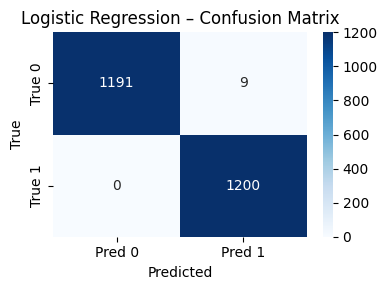

['insider_logreg_baseline.pkl']

In [6]:
# Step 5: Logistic Regression baseline

log_reg_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_clf.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

# Metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
roc_lr  = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression – Test metrics")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1       : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_lr:.4f}\n")

print("Classification report:\n")
print(classification_report(y_test, y_pred_lr,
                            target_names=["Outsider (0)", "Insider (1)"]))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["True 0","True 1"])
plt.title("Logistic Regression – Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Save the pipeline (preprocessing + model together)
joblib.dump(log_reg_clf, "insider_logreg_baseline.pkl")


Random Forest – Test metrics
Accuracy : 0.9962
Precision: 0.9926
Recall   : 1.0000
F1       : 0.9963
ROC-AUC  : 1.0000

Classification report:

              precision    recall  f1-score   support

Outsider (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



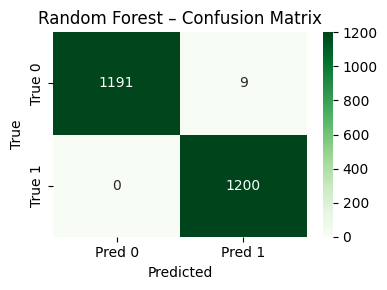

['insider_random_forest.pkl']

In [7]:
# Step 6: Random Forest model

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
roc_rf  = roc_auc_score(y_test, y_proba_rf)

print("Random Forest – Test metrics")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1       : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_rf:.4f}\n")

print("Classification report:\n")
print(classification_report(y_test, y_pred_rf,
                            target_names=["Outsider (0)", "Insider (1)"]))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["True 0","True 1"])
plt.title("Random Forest – Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Save model
joblib.dump(rf_clf, "insider_random_forest.pkl")


Insider Threat – Model Comparison


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9962,0.9926,1.0,0.9963,1.0
Random Forest,0.9962,0.9926,1.0,0.9963,1.0


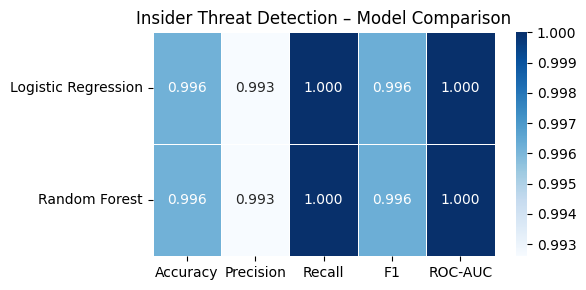

In [8]:
# Step 7: Model comparison table + heatmap

results = {
    "Logistic Regression": {
        "Accuracy": acc_lr,
        "Precision": prec_lr,
        "Recall": rec_lr,
        "F1": f1_lr,
        "ROC-AUC": roc_lr
    },
    "Random Forest": {
        "Accuracy": acc_rf,
        "Precision": prec_rf,
        "Recall": rec_rf,
        "F1": f1_rf,
        "ROC-AUC": roc_rf
    }
}

df_results = pd.DataFrame(results).T.round(4)
print("Insider Threat – Model Comparison")
display(df_results)

plt.figure(figsize=(6,3))
sns.heatmap(df_results.astype(float), annot=True, fmt=".3f",
            cmap="Blues", cbar=True, linewidths=.5)
plt.title("Insider Threat Detection – Model Comparison")
plt.tight_layout()
plt.show()


In [11]:
!git clone https://github.com/egyinmoe/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation.git


Cloning into 'Detecting-Insider-Threats-through-Behavioral-AI_Dissertation'...


In [12]:
%cd Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


In [13]:
!git status


On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [15]:
!ls -al /content


total 3904
drwxr-xr-x 1 root root    4096 Nov 17 22:59 .
drwxr-xr-x 1 root root    4096 Nov 17 22:49 ..
drwxr-xr-x 4 root root    4096 Nov 12 14:30 .config
drwxr-xr-x 3 root root    4096 Nov 17 22:59 Detecting-Insider-Threats-through-Behavioral-AI_Dissertation
drwx------ 5 root root    4096 Nov 17 22:51 drive
-rw-r--r-- 1 root root   14017 Nov 17 22:54 insider_logreg_baseline.pkl
-rw-r--r-- 1 root root 3954898 Nov 17 22:55 insider_random_forest.pkl
drwxr-xr-x 1 root root    4096 Nov 12 14:30 sample_data


In [16]:
!find / -name "*.ipynb" 2>/dev/null


/usr/local/lib/python3.12/dist-packages/notebook/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/nbclassic/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/panel/tests/ui/io/app.ipynb
/usr/local/lib/python3.12/dist-packages/libpysal/cg/tests/fast_point_in_polygon_algorithm.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/1-Introduction.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/5-Live_Data.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/2-Customization.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/3-Tabular_Datasets.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/4-Gridded_Datasets.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/features/bokeh/Scalebar.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/features/bo